<a href="https://colab.research.google.com/github/yadavrishikesh/Masterclass-IITMandi/blob/main/Module1/code/data_visualisation_GoogleColab_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from pathlib import Path

# Set clean white background
plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

# Define the path to the data file
data_file = 'https://raw.githubusercontent.com/yadavrishikesh/Masterclass-IITMandi/refs/heads/main/Module1/data/PM2.5/2010_data.csv'

# Load data and calculate yearly averages
df = pd.read_csv(data_file)

# Extract time columns (excluding 'lat' and 'lon')
time_cols = [col for col in df.columns if col not in ['lat', 'lon']]

years = []
yearly_values = []

for col in time_cols:
    year = int(col[:4])
    if year not in years:
        years.append(year)
        year_cols = [c for c in time_cols if c.startswith(str(year))]
        yearly_avg = df[year_cols].mean().mean()
        yearly_values.append(yearly_avg)

# Sort years and values
years, yearly_values = zip(*sorted(zip(years, yearly_values)))

# Display the first few rows of the dataframe
df.head(5)


,lat,lon,2010-01,2010-02,2010-03,2010-04,2010-05,2010-06,2010-07,2010-08,2010-09,2010-10,2010-11,2010-12
0,29.0,72.500,1.560905e-08,2.798957e-08,4.731708e-08,7.292935e-08,1.161041e-07,1.536385e-07,8.196167e-08,5.622179e-08,3.554233e-08,3.831613e-08,1.815115e-08,2.303345e-08
1,29.0,73.125,1.538724e-08,3.070558e-08,4.112770e-08,6.539606e-08,9.873264e-08,1.219505e-07,7.208104e-08,4.182414e-08,2.582125e-08,3.280811e-08,1.780039e-08,1.851004e-08
2,29.0,73.750,1.507587e-08,3.112317e-08,3.648153e-08,5.840581e-08,9.024863e-08,9.962993e-08,6.653464e-08,3.112150e-08,1.855454e-08,2.901675e-08,1.814630e-08,1.715847e-08
3,29.0,74.375,1.455042e-08,2.711633e-08,3.262504e-08,5.052425e-08,7.976233e-08,8.477873e-08,5.599471e-08,2.143397e-08,1.365872e-08,2.665054e-08,1.788236e-08,1.649559e-08
4,29.0,75.000,1.401091e-08,2.428663e-08,2.992320e-08,4.387790e-08,6.914366e-08,7.092118e-08,4.662950e-08,1.680740e-08,1.054265e-08,2.552288e-08,1.732363e-08,1.683196e-08


In [ ]:
import requests

def download_shapefiles():
    shapefile_dir = Path("India Shape")
    shapefile_dir.mkdir(parents=True, exist_ok=True)

    base_url = "https://raw.githubusercontent.com/yadavrishikesh/Masterclass-IITMandi/main/Module1/data/India Shape"
    files = ['india_st.shp', 'india_st.shx', 'india_st.dbf']

    for fname in files:
        url = f"{base_url}/{fname}"
        local_path = shapefile_dir / fname
        if not local_path.exists():
            print(f"Downloading {fname}...")
            r = requests.get(url)
            if r.status_code == 200:
                with open(local_path, 'wb') as f:
                    f.write(r.content)
            else:
                raise Exception(f"Failed to download {fname}: {r.status_code}")


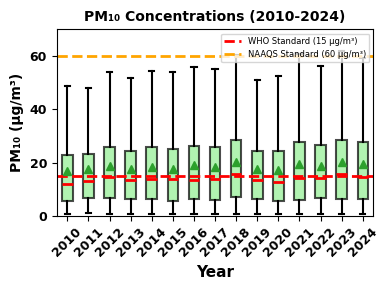

Plot saved for 15 years: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


<Figure size 640x480 with 0 Axes>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Plot settings
plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

# Base GitHub URL
base_url = "https://raw.githubusercontent.com/yadavrishikesh/Masterclass-IITMandi/main/Module1/data/PM10"

all_data = []
years = []

for year in range(2010, 2025):
    file_url = f"{base_url}/{year}_data.csv"
    try:
        df = pd.read_csv(file_url)
        # Get monthly columns (exclude lat, lon)
        monthly_cols = [col for col in df.columns if col not in ['lat', 'lon']]
        year_values = []
        for col in monthly_cols:
            values = df[col].dropna()
            year_values.extend(values)

        if len(year_values) > 0:
            all_data.append(year_values)
            years.append(year)

    except Exception as e:
        print(f"Error loading data for year {year}: {e}")

# Plot boxplot
plt.figure(figsize=(4, 3))
bp = plt.boxplot(all_data, labels=years, showmeans=True, showfliers=False, patch_artist=True)

# Style the boxes
for box in bp['boxes']:
    box.set(facecolor='lightgreen', alpha=0.7, linewidth=1.5)
for whisker in bp['whiskers']:
    whisker.set(linewidth=1.5, color='black')
for cap in bp['caps']:
    cap.set(linewidth=1.5, color='black')
for median in bp['medians']:
    median.set(linewidth=2, color='red')

# Reference lines
plt.axhline(y=15, color='red', linestyle='--', linewidth=2, label='WHO Standard (15 µg/m³)')
plt.axhline(y=60, color='orange', linestyle='--', linewidth=2, label='NAAQS Standard (60 µg/m³)')

plt.xlabel('Year', fontweight='bold', fontsize=11)
plt.ylabel('PM₁₀ (µg/m³)', fontweight='bold', fontsize=10)
plt.title('PM₁₀ Concentrations (2010-2024)', fontweight='bold', fontsize=10)
plt.ylim(0, 70)
plt.xticks(rotation=45, fontweight='bold', fontsize=9)
plt.yticks(fontweight='bold', fontsize=9)
plt.legend(loc='upper right', fontsize=6)
plt.tight_layout()
plt.show()

# Save plot
plt.savefig('PM10_boxplot.png', dpi=300, bbox_inches='tight')
print(f"Plot saved for {len(years)} years: {years}")


BOX PLOTS

✅ Loaded 2010_data.csv from GitHub.
✅ Loaded 2011_data.csv from GitHub.
✅ Loaded 2012_data.csv from GitHub.
✅ Loaded 2013_data.csv from GitHub.
✅ Loaded 2014_data.csv from GitHub.
✅ Loaded 2015_data.csv from GitHub.
✅ Loaded 2016_data.csv from GitHub.
✅ Loaded 2017_data.csv from GitHub.
✅ Loaded 2018_data.csv from GitHub.
✅ Loaded 2019_data.csv from GitHub.
✅ Loaded 2020_data.csv from GitHub.
✅ Loaded 2021_data.csv from GitHub.
✅ Loaded 2022_data.csv from GitHub.
✅ Loaded 2023_data.csv from GitHub.
✅ Loaded 2024_data.csv from GitHub.


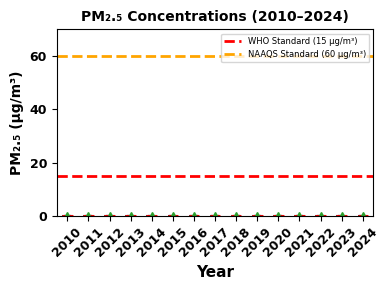

📈 Plot saved for 15 years: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]


<Figure size 640x480 with 0 Axes>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Plot styling
plt.style.use('default')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

# GitHub raw URL base for PM2.5
base_url = "https://raw.githubusercontent.com/yadavrishikesh/Masterclass-IITMandi/main/Module1/data/PM2.5"

all_data = []
years = []

for year in range(2010, 2025):
    file_url = f"{base_url}/{year}_data.csv"
    try:
        df = pd.read_csv(file_url)
        print(f"✅ Loaded {year}_data.csv from GitHub.")

        # Exclude lat, lon columns
        monthly_cols = [col for col in df.columns if col not in ['lat', 'lon']]
        year_values = []
        for col in monthly_cols:
            values = df[col].dropna()
            year_values.extend(values)

        if year_values:
            all_data.append(year_values)
            years.append(year)
        else:
            print(f"⚠️  No data values found for year {year}.")
    except Exception as e:
        print(f"❌ Could not load data for year {year}: {e}")

# Create box plot
plt.figure(figsize=(4, 3))
bp = plt.boxplot(all_data, labels=years, showmeans=True, showfliers=False, patch_artist=True)

# Style the boxes
for box in bp['boxes']:
    box.set(facecolor='lightgreen', alpha=0.7, linewidth=1.5)
for whisker in bp['whiskers']:
    whisker.set(linewidth=1.5, color='black')
for cap in bp['caps']:
    cap.set(linewidth=1.5, color='black')
for median in bp['medians']:
    median.set(linewidth=2, color='red')

# WHO & NAAQS standards
plt.axhline(y=15, color='red', linestyle='--', linewidth=2, label='WHO Standard (15 µg/m³)')
plt.axhline(y=60, color='orange', linestyle='--', linewidth=2, label='NAAQS Standard (60 µg/m³)')

# Labels and formatting
plt.xlabel('Year', fontweight='bold', fontsize=11)
plt.ylabel('PM₂.₅ (µg/m³)', fontweight='bold', fontsize=10)
plt.title('PM₂.₅ Concentrations (2010–2024)', fontweight='bold', fontsize=10)
plt.ylim(0, 70)
plt.xticks(rotation=45, fontweight='bold', fontsize=9)
plt.yticks(fontweight='bold', fontsize=9)
plt.legend(loc='upper right', fontsize=6)
plt.tight_layout()
plt.show()

# Save plot
plt.savefig('PM25_boxplot.png', dpi=300, bbox_inches='tight')
print(f"📈 Plot saved for {len(years)} years: {years}")

❌ Failed to process data for 2024: HTTP Error 404: Not Found


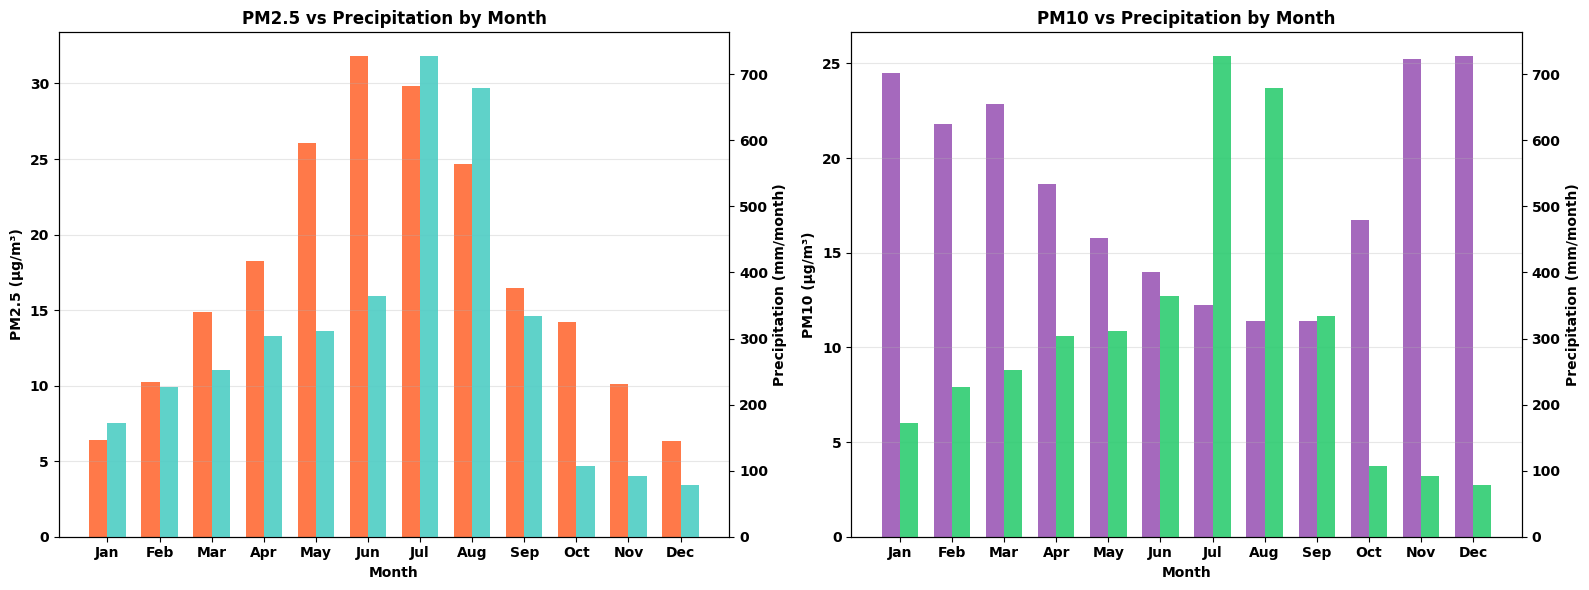

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# GitHub raw URL bases
pm25_base_url = "https://raw.githubusercontent.com/yadavrishikesh/Masterclass-IITMandi/main/Module1/data/PM2.5"
pm10_base_url = "https://raw.githubusercontent.com/yadavrishikesh/Masterclass-IITMandi/main/Module1/data/PM10"
prec_base_url = "https://raw.githubusercontent.com/yadavrishikesh/Masterclass-IITMandi/main/Module1/data/PREC"

# Collect monthly data from GitHub
def collect_monthly_data(pm25_url, pm10_url, prec_url):
    pm25_monthly = {i: [] for i in range(1, 13)}
    pm10_monthly = {i: [] for i in range(1, 13)}
    prec_monthly = {i: [] for i in range(1, 13)}

    for year in range(2010, 2025):
        try:
            df_pm25 = pd.read_csv(f"{pm25_url}/{year}_data.csv")
            df_pm10 = pd.read_csv(f"{pm10_url}/{year}_data.csv")
            df_prec = pd.read_csv(f"{prec_url}/{year}_pdata.csv")

            for month in range(1, 13):
                month_pattern = f"{year}-{month:02d}"

                # PM2.5
                pm25_cols = [col for col in df_pm25.columns if col.startswith(month_pattern)]
                if pm25_cols:
                    values = df_pm25[pm25_cols].values.flatten()
                    clean_values = values[~pd.isna(values)] * 1e9  # Convert from g/m³ to µg/m³
                    pm25_monthly[month].extend(clean_values)

                # PM10
                pm10_cols = [col for col in df_pm10.columns if col.startswith(month_pattern)]
                if pm10_cols:
                    values = df_pm10[pm10_cols].values.flatten()
                    clean_values = values[~pd.isna(values)]
                    pm10_monthly[month].extend(clean_values)

                # Precipitation
                prec_cols = [col for col in df_prec.columns if col.startswith(month_pattern)]
                if prec_cols:
                    values = df_prec[prec_cols].values.flatten()
                    clean_values = values[~pd.isna(values)] * 86400 * 30  # Convert from m/s to mm/month
                    prec_monthly[month].extend(clean_values)
        except Exception as e:
            print(f"❌ Failed to process data for {year}: {e}")
            continue

    return pm25_monthly, pm10_monthly, prec_monthly

# Fetch data from GitHub
pm25_monthly, pm10_monthly, prec_monthly = collect_monthly_data(pm25_base_url, pm10_base_url, prec_base_url)

# Compute monthly means
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
pm25_means = [np.mean(pm25_monthly[i+1]) if pm25_monthly[i+1] else 0 for i in range(12)]
pm10_means = [np.mean(pm10_monthly[i+1]) if pm10_monthly[i+1] else 0 for i in range(12)]
prec_means = [np.mean(prec_monthly[i+1]) if prec_monthly[i+1] else 0 for i in range(12)]

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
x = np.arange(12)
width = 0.35

# Plot 1: PM2.5 vs Precipitation
ax1_twin = ax1.twinx()
ax1.bar(x - width/2, pm25_means, width, label='PM2.5', color='#FF6B35', alpha=0.9)
ax1_twin.bar(x + width/2, prec_means, width, label='Precipitation', color='#4ECDC4', alpha=0.9)

ax1.set_xlabel('Month', fontweight='bold')
ax1.set_ylabel('PM2.5 (µg/m³)', fontweight='bold')
ax1_twin.set_ylabel('Precipitation (mm/month)', fontweight='bold')
ax1.set_title('PM2.5 vs Precipitation by Month', fontweight='bold')

ax1.set_xticks(x)
ax1.set_xticklabels(months, fontweight='bold')
ax1.tick_params(axis='y', labelsize=10)
ax1.set_yticklabels([f'{tick:.0f}' for tick in ax1.get_yticks()], fontweight='bold')
ax1_twin.tick_params(axis='y', labelsize=10)
ax1_twin.set_yticklabels([f'{tick:.0f}' for tick in ax1_twin.get_yticks()], fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Plot 2: PM10 vs Precipitation
ax2_twin = ax2.twinx()
ax2.bar(x - width/2, pm10_means, width, label='PM10', color='#9B59B6', alpha=0.9)
ax2_twin.bar(x + width/2, prec_means, width, label='Precipitation', color='#2ECC71', alpha=0.9)

ax2.set_xlabel('Month', fontweight='bold')
ax2.set_ylabel('PM10 (µg/m³)', fontweight='bold')
ax2_twin.set_ylabel('Precipitation (mm/month)', fontweight='bold')
ax2.set_title('PM10 vs Precipitation by Month', fontweight='bold')

ax2.set_xticks(x)
ax2.set_xticklabels(months, fontweight='bold')
ax2.tick_params(axis='y', labelsize=10)
ax2.set_yticklabels([f'{tick:.0f}' for tick in ax2.get_yticks()], fontweight='bold')
ax2_twin.tick_params(axis='y', labelsize=10)
ax2_twin.set_yticklabels([f'{tick:.0f}' for tick in ax2_twin.get_yticks()], fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

BAR PLOTS

SCATTER PLOTS

Skipped year 2024: HTTP Error 404: Not Found


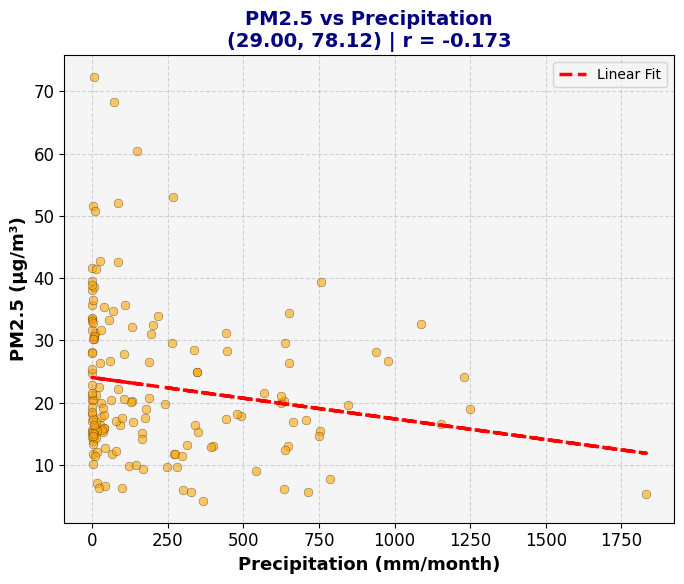

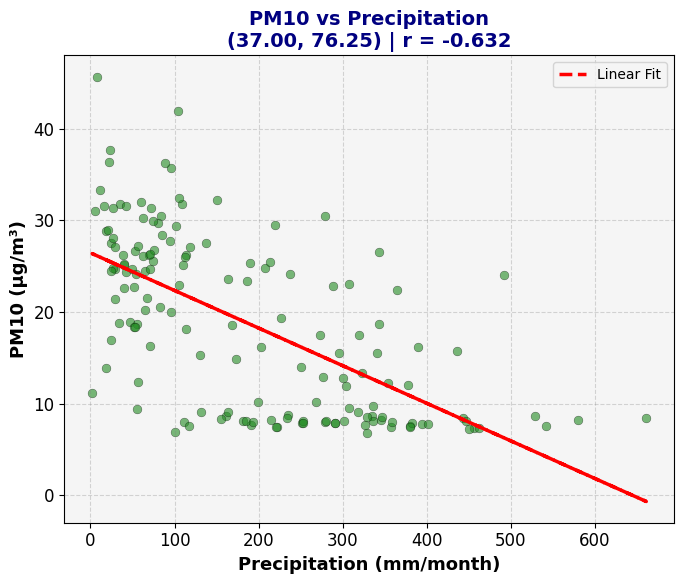

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from matplotlib import rcParams

# Aesthetic settings
rcParams.update({
    'font.size': 12,
    'font.family': 'DejaVu Sans',
    'axes.labelweight': 'bold',
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'figure.facecolor': 'white',
    'axes.facecolor': '#f5f5f5',
    'grid.color': 'gray',
    'grid.alpha': 0.3
})

# === Function to find max negative correlation ===
def find_max_negative_correlation(base_url_pm25, base_url_pm10, base_url_prec):
    grid_corr_pm25 = {}
    grid_corr_pm10 = {}

    for year in range(2010, 2025):
        try:
            df_pm25 = pd.read_csv(f"{base_url_pm25}/{year}_data.csv")
            df_pm10 = pd.read_csv(f"{base_url_pm10}/{year}_data.csv")
            df_prec = pd.read_csv(f"{base_url_prec}/{year}_pdata.csv")
        except Exception as e:
            print(f"Skipped year {year}: {e}")
            continue

        for index, row in df_pm25.iterrows():
            lat, lon = row['lat'], row['lon']
            key = (lat, lon)

            try:
                pm25_vals = row.drop(['lat', 'lon']).astype(float).values * 1e9
                pm10_vals = df_pm10.loc[index].drop(['lat', 'lon']).astype(float).values
                prec_vals = df_prec.loc[index].drop(['lat', 'lon']).astype(float).values * 86400 * 30

                valid = (~np.isnan(pm25_vals)) & (~np.isnan(pm10_vals)) & (~np.isnan(prec_vals))
                if valid.sum() < 10:
                    continue

                # Initialize key if not present
                if key not in grid_corr_pm25:
                    grid_corr_pm25[key] = [[], []]
                    grid_corr_pm10[key] = [[], []]

                # Append valid values
                grid_corr_pm25[key][0].extend(prec_vals[valid])
                grid_corr_pm25[key][1].extend(pm25_vals[valid])
                grid_corr_pm10[key][0].extend(prec_vals[valid])
                grid_corr_pm10[key][1].extend(pm10_vals[valid])
            except Exception:
                continue

    # Compute Pearson correlations
    def compute_corr(data_dict):
        results = {}
        for key, (x, y) in data_dict.items():
            if len(x) > 10:
                try:
                    corr, _ = pearsonr(x, y)
                    if not np.isnan(corr):
                        results[key] = corr
                except:
                    continue
        return results

    corr_results_pm25 = compute_corr(grid_corr_pm25)
    corr_results_pm10 = compute_corr(grid_corr_pm10)

    min_corr_pm25 = min(corr_results_pm25.items(), key=lambda x: x[1])
    min_corr_pm10 = min(corr_results_pm10.items(), key=lambda x: x[1])

    return min_corr_pm25, min_corr_pm10, grid_corr_pm25, grid_corr_pm10

# === Scatter Plot Function ===
def plot_scatter(x, y, title, xlab, ylab, point_color, filename=None):
    plt.figure(figsize=(7, 6))
    plt.scatter(x, y, alpha=0.6, color=point_color, edgecolors='k', linewidths=0.3, s=40)

    # Trendline
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    plt.plot(x, p(x), 'r--', linewidth=2.5, label=f'Linear Fit')

    plt.xlabel(xlab, fontsize=13, fontweight='bold')
    plt.ylabel(ylab, fontsize=13, fontweight='bold')
    plt.title(title, fontsize=14, fontweight='bold', color='navy')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.legend(loc='best', fontsize=10)
    plt.tight_layout()

    if filename:
        plt.savefig(filename, dpi=300)
    plt.show()

# === GitHub Paths ===
base_url_pm25 = "https://raw.githubusercontent.com/yadavrishikesh/Masterclass-IITMandi/main/Module1/data/PM2.5"
base_url_pm10 = "https://raw.githubusercontent.com/yadavrishikesh/Masterclass-IITMandi/main/Module1/data/PM10"
base_url_prec = "https://raw.githubusercontent.com/yadavrishikesh/Masterclass-IITMandi/main/Module1/data/PREC"

# === Get Correlation Results ===
min_pm25_result, min_pm10_result, full_pm25_data, full_pm10_data = find_max_negative_correlation(
    base_url_pm25, base_url_pm10, base_url_prec
)

# === Extract Coordinates and Correlation ===
(lat_pm25, lon_pm25), corr_pm25 = min_pm25_result
(lat_pm10, lon_pm10), corr_pm10 = min_pm10_result

# === Plot PM2.5 ===
x1 = full_pm25_data[(lat_pm25, lon_pm25)][0]
y1 = full_pm25_data[(lat_pm25, lon_pm25)][1]
plot_scatter(
    x1, y1,
    title=f'PM2.5 vs Precipitation\n({lat_pm25:.2f}, {lon_pm25:.2f}) | r = {corr_pm25:.3f}',
    xlab='Precipitation (mm/month)',
    ylab='PM2.5 (µg/m³)',
    point_color='orange',
    filename='pm25_vs_precip.png'
)

# === Plot PM10 ===
x2 = full_pm10_data[(lat_pm10, lon_pm10)][0]
y2 = full_pm10_data[(lat_pm10, lon_pm10)][1]
plot_scatter(
    x2, y2,
    title=f'PM10 vs Precipitation\n({lat_pm10:.2f}, {lon_pm10:.2f}) | r = {corr_pm10:.3f}',
    xlab='Precipitation (mm/month)',
    ylab='PM10 (µg/m³)',
    point_color='forestgreen',
    filename='pm10_vs_precip.png'
)

HEATMAPS

✅ Total unique coordinates found: 255

✅ Target location found: (29.5, 78.75)
  PM2.5 vs Precipitation: -0.529
  PM2.5 vs Windspeed:     -0.369


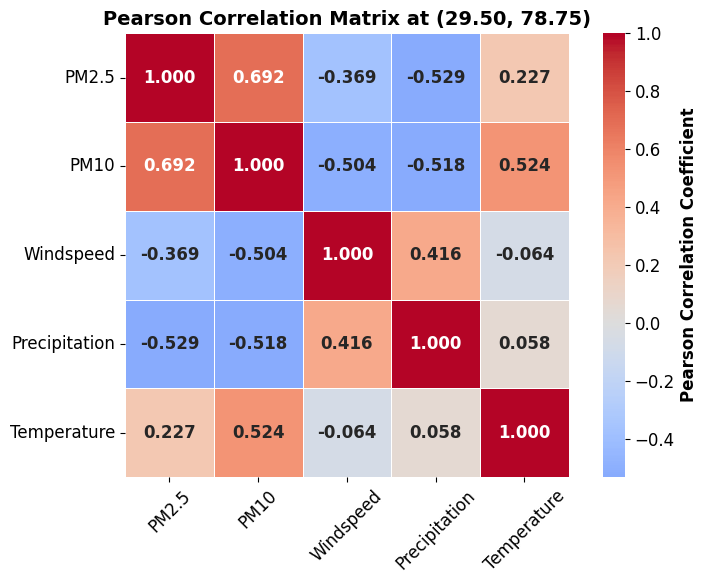

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# GitHub base URL
base_url = "https://raw.githubusercontent.com/yadavrishikesh/Masterclass-IITMandi/main/Module1/data"

years = list(range(2010, 2025))
parameters = {
    'PM2.5': {'folder': 'PM2.5', 'patterns': ['{year}_data.csv', '{year}_pm25data.csv', '{year}_pm2.5data.csv']},
    'PM10': {'folder': 'PM10', 'patterns': ['{year}_data.csv', '{year}_pm10data.csv']},
    'Windspeed': {'folder': 'Wind_Speed', 'patterns': ['{year}_data.csv', '{year}_winddata.csv']},
    'Precipitation': {'folder': 'PREC', 'patterns': ['{year}_data.csv', '{year}_pdata.csv']},
    'Temperature': {'folder': 'TEMP', 'patterns': ['{year}_data.csv', '{year}_tdata.csv']}
}

# Helper: try downloading a file from GitHub
def try_read_url(folder, year, patterns):
    for pattern in patterns:
        url = f"{base_url}/{folder}/{pattern.format(year=year)}"
        try:
            df = pd.read_csv(url)
            return df
        except:
            continue
    return None

# Step 1: Gather unique coordinates from PM2.5
all_coords = set()
for year in years:
    df = try_read_url('PM2.5', year, parameters['PM2.5']['patterns'])
    if df is not None and 'lat' in df.columns and 'lon' in df.columns:
        coords = set(zip(df['lat'], df['lon']))
        all_coords.update(coords)

print(f"✅ Total unique coordinates found: {len(all_coords)}")

# Helper: get yearly mean value for a parameter at a location
def get_param_value(df, lat, lon, param):
    row = df[(df['lat'] == lat) & (df['lon'] == lon)]
    if row.empty:
        return np.nan
    val = row.drop(columns=['lat', 'lon']).mean(axis=1).values[0]

    # Unit conversions
    if param == 'PM2.5':
        val *= 1e9
    elif param == 'Temperature' and val > 200:
        val -= 273.15
    elif param == 'Precipitation':
        val *= 30.44 * 24 * 3600  # m/s to mm/month
    return val

# Step 2: Loop through coordinates
for (lat, lon) in sorted(all_coords):
    data = {param: [] for param in parameters}

    for param, info in parameters.items():
        for year in years:
            df = try_read_url(info['folder'], year, info['patterns'])
            if df is None or 'lat' not in df.columns or 'lon' not in df.columns:
                data[param].append(np.nan)
                continue
            try:
                val = get_param_value(df, lat, lon, param)
                data[param].append(val)
            except Exception as e:
                print(f"⚠️ Error processing {param} {year} at ({lat}, {lon}): {e}")
                data[param].append(np.nan)

    df = pd.DataFrame(data, index=years).dropna(how='all')
    if df.shape[0] < 5:
        continue

    corr_matrix = df.corr(method='pearson')

    cond_prec_pm25 = 'Precipitation' in corr_matrix and 'PM2.5' in corr_matrix and \
                     corr_matrix.loc['Precipitation', 'PM2.5'] < -0.3
    cond_wind_pm25 = 'Windspeed' in corr_matrix and 'PM2.5' in corr_matrix and \
                     corr_matrix.loc['Windspeed', 'PM2.5'] < -0.3

    if cond_prec_pm25 and cond_wind_pm25:
        print(f"\n✅ Target location found: ({lat}, {lon})")
        print(f"  PM2.5 vs Precipitation: {corr_matrix.loc['Precipitation', 'PM2.5']:.3f}")
        print(f"  PM2.5 vs Windspeed:     {corr_matrix.loc['Windspeed', 'PM2.5']:.3f}")

        plt.figure(figsize=(8, 6))
        sns.heatmap(
            corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, annot_kws={'size': 12, 'weight': 'bold'},
            cbar_kws={'label': 'Pearson Correlation Coefficient'}
        )
        plt.title(f'Pearson Correlation Matrix at ({lat:.2f}, {lon:.2f})', fontsize=14, fontweight='bold')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        break  # Stop after the first match

SPATIAL PLOT FOR PM2.5

Reading data from https://raw.githubusercontent.com/yadavrishikesh/Masterclass-IITMandi/refs/heads/main/Module1/data/PM2.5/2010_data.csv
Loaded 3060 records.
Loading shapefile...
Shapefile loaded with 32 features
Filtered to Western Himalayas: 2856 records
Within shapefile boundary: 1680 records
Winter max: 21.13
Summer max: 58.99
Monsoon max: 65.42


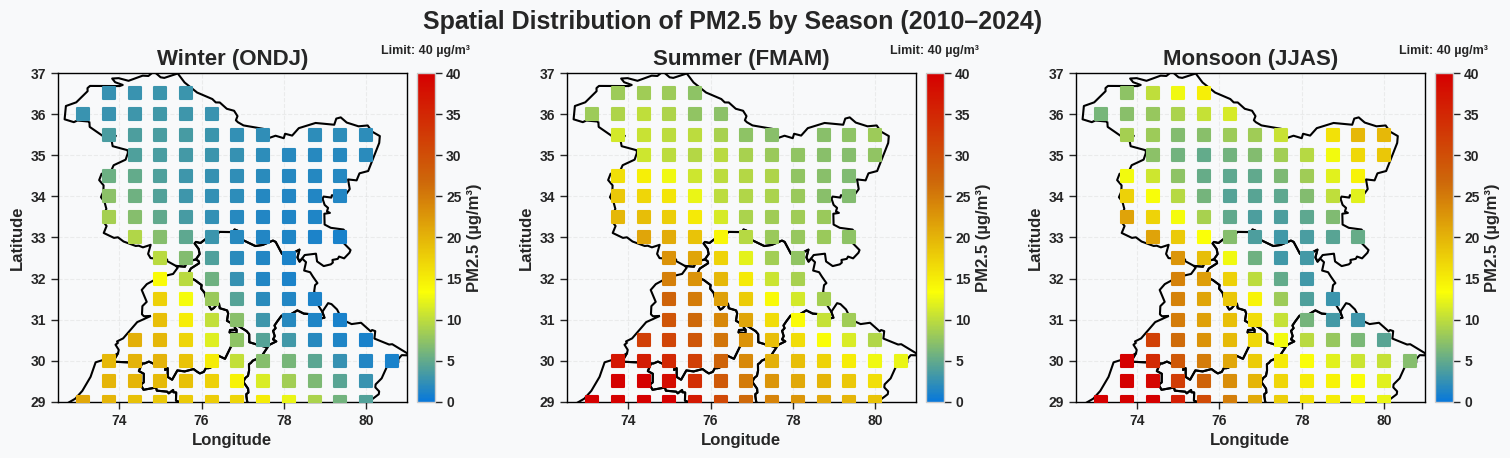

Plot saved to: PM2.5_plot/PM25_seasons_stacked_fixed_scale.png


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import geopandas as gpd
from mpl_toolkits.axes_grid1 import make_axes_locatable
from shapely.geometry import Point
from pathlib import Path
import requests

# ======== Global Path Settings ========
BASE_DIR = Path('.')
DATA_DIR = BASE_DIR / 'PM2.5'
SHAPE_DIR = BASE_DIR / 'india_shape'
OUTPUT_DIR = BASE_DIR / 'PM2.5_plot'
PM25_COLORBAR_MAX = 40  # µg/m³ limit for PM2.5

# ======== GitHub Raw URLs for .shp, .dbf, .shx ========
GITHUB_BASE = "https://raw.githubusercontent.com/yadavrishikesh/Masterclass-IITMandi/main/Module1/data/India Shape"
SHAPEFILES = ['india_st.shp', 'india_st.shx', 'india_st.dbf']

def download_shapefiles():
    SHAPE_DIR.mkdir(parents=True, exist_ok=True)
    for fname in SHAPEFILES:
        url = f"{GITHUB_BASE}/{fname}"
        local_path = SHAPE_DIR / fname
        if not local_path.exists():
            print(f"Downloading {fname}...")
            r = requests.get(url)
            if r.status_code == 200:
                with open(local_path, 'wb') as f:
                    f.write(r.content)
            else:
                raise Exception(f"Failed to download {fname} from GitHub. Status code: {r.status_code}")

# ======== Plotting Settings ========
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)
colors = ["#0878DA", "#FBFF07", "#CE690A", '#D50000']
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['figure.titleweight'] = 'bold'


def load_all_pm25_data(start_year=2010, end_year=2024):
  all_data = []
  base_url = "https://raw.githubusercontent.com/yadavrishikesh/Masterclass-IITMandi/refs/heads/main/Module1/data/PM2.5/"

  for year in range(start_year, end_year + 1):
      file_url = f"{base_url}{year}_data.csv"
      try:
          print(f"Reading data from {file_url}")
          df = pd.read_csv(file_url)
          id_vars = ['lat', 'lon']
          value_vars = [col for col in df.columns if col.startswith(f'{year}-')]
          df_long = pd.melt(df, id_vars=id_vars, value_vars=value_vars,
                            var_name='date', value_name='pm25')
          df_long['pm25'] = df_long['pm25'] * 1e9
          df_long['month'] = df_long['date'].str.split('-').str[1].astype(int)
          df_long['year'] = year
          all_data.append(df_long)
      except Exception as e:
          print(f"⚠️ Failed to load {file_url}: {e}")

      if all_data:
          return pd.concat(all_data, ignore_index=True)
      else:
          raise ValueError("❌ No data files loaded from GitHub!")


def define_seasons(df):
    season_map = {
        1: 'Winter', 2: 'Summer', 3: 'Summer', 4: 'Summer', 5: 'Summer',
        6: 'Monsoon', 7: 'Monsoon', 8: 'Monsoon', 9: 'Monsoon',
        10: 'Winter', 11: 'Winter', 12: 'Winter'
    }
    df['season'] = df['month'].map(season_map)
    return df

def plot_seasons_stacked(df, shapefile_path, output_dir=OUTPUT_DIR):
    print("Loading shapefile...")
    try:
        gdf = gpd.read_file(shapefile_path)
        print(f"Shapefile loaded with {len(gdf)} features")
        dissolved_shape = gdf.dissolve().reset_index()
        boundary_polygon = dissolved_shape.iloc[0].geometry
    except Exception as e:
        print(f"Error loading shapefile: {e}")
        gdf = None
        boundary_polygon = None

    seasons = ['Winter', 'Summer', 'Monsoon']
    season_labels = ['ONDJ', 'FMAM', 'JJAS']

    wh_bounds = {'min_lat': 29, 'max_lat': 37.0, 'min_lon': 72.5, 'max_lon': 81.0}
    wh_df = df[(df['lon'] >= wh_bounds['min_lon']) &
               (df['lon'] <= wh_bounds['max_lon']) &
               (df['lat'] >= wh_bounds['min_lat']) &
               (df['lat'] <= wh_bounds['max_lat'])]

    print(f"Filtered to Western Himalayas: {len(wh_df)} records")

    if boundary_polygon is not None:
        geometry = [Point(xy) for xy in zip(wh_df['lon'], wh_df['lat'])]
        mask = [boundary_polygon.contains(point) for point in geometry]
        wh_df = wh_df[mask]
        print(f"Within shapefile boundary: {len(wh_df)} records")

    wh_df = define_seasons(wh_df)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor='white', gridspec_kw={'wspace': 0.35})
    fig.suptitle('Spatial Distribution of PM2.5 by Season (2010–2024)', fontsize=18, fontweight='bold', y=0.95)
    fig.patch.set_facecolor('#f8f9fa')

    custom_cmap = LinearSegmentedColormap.from_list('custom_cmap', colors, N=256)
    norm = plt.Normalize(vmin=0, vmax=PM25_COLORBAR_MAX)

    for i, (season, label) in enumerate(zip(seasons, season_labels)):
        ax = axes[i]
        ax.set_facecolor('#f8f9fa')
        season_data = wh_df[wh_df['season'] == season]
        location_means = season_data.groupby(['lat', 'lon'])['pm25'].mean().reset_index()
        actual_max = location_means['pm25'].max() if not location_means.empty else 0
        print(f"{season} max: {actual_max:.2f}")

        if location_means.empty:
            ax.set_title(f"{season} ({label}) - No Data", fontsize=16, fontweight='bold')
            continue

        if gdf is not None:
            gdf.boundary.plot(ax=ax, color='black', linewidth=1.5, alpha=1.0, zorder=1)

        for _, row in location_means.iterrows():
            color = custom_cmap(norm(row['pm25']))
            ax.scatter(row['lon'], row['lat'], c=[color], alpha=1.0, s=70,
                       marker='s', edgecolors=color, linewidths=1.5, zorder=5)

        scatter = ax.scatter([], [], c=[], cmap=custom_cmap, norm=norm, s=0)
        ax.set_xlim(wh_bounds['min_lon'], wh_bounds['max_lon'])
        ax.set_ylim(wh_bounds['min_lat'], wh_bounds['max_lat'])

        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.1)
        cbar = plt.colorbar(scatter, cax=cax)
        cbar.set_label('PM2.5 (µg/m³)', fontsize=12, fontweight='bold')
        cbar.ax.tick_params(labelsize=10)
        cbar.ax.text(0.5, 1.05, f"Limit: {PM25_COLORBAR_MAX} µg/m³",
                     transform=cbar.ax.transAxes, ha='center', va='bottom',
                     fontsize=9, fontweight='bold')

        ax.set_title(f"{season} ({label})", fontsize=16, fontweight='bold')
        ax.set_xlabel('Longitude', fontsize=12, fontweight='bold')
        ax.set_ylabel('Latitude', fontsize=12, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.1, color='#707070')
        ax.tick_params(axis='both', labelsize=10)

        for tick in ax.get_xticklabels() + ax.get_yticklabels():
            tick.set_fontweight('bold')

        for spine in ax.spines.values():
            spine.set_linewidth = 2.0
            spine.set_color('black')

    plt.tight_layout(rect=[0, 0.03, 1, 0.92])
    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / 'PM25_seasons_stacked_fixed_scale.png'
    plt.show()
    print(f"Plot saved to: {output_path}")
    plt.close()


def main():
    try:
        print("Downloading shapefiles...")
        download_shapefiles()
        df = load_all_pm25_data()
        print(f"Loaded {len(df)} records.")
        plot_seasons_stacked(df, shapefile_path=SHAPE_DIR / 'india_st.shp')
    except Exception as e:
        print(f"Error: {e}")
        import traceback
        traceback.print_exc()

if __name__ == "__main__":
    main()

Loading PM2.5 data...
Reading data from https://raw.githubusercontent.com/yadavrishikesh/Masterclass-IITMandi/refs/heads/main/Module1/data/PM2.5/2010_data.csv
Reading data from https://raw.githubusercontent.com/yadavrishikesh/Masterclass-IITMandi/refs/heads/main/Module1/data/PM2.5/2011_data.csv
Reading data from https://raw.githubusercontent.com/yadavrishikesh/Masterclass-IITMandi/refs/heads/main/Module1/data/PM2.5/2012_data.csv
Reading data from https://raw.githubusercontent.com/yadavrishikesh/Masterclass-IITMandi/refs/heads/main/Module1/data/PM2.5/2013_data.csv
Reading data from https://raw.githubusercontent.com/yadavrishikesh/Masterclass-IITMandi/refs/heads/main/Module1/data/PM2.5/2014_data.csv
Reading data from https://raw.githubusercontent.com/yadavrishikesh/Masterclass-IITMandi/refs/heads/main/Module1/data/PM2.5/2015_data.csv
Reading data from https://raw.githubusercontent.com/yadavrishikesh/Masterclass-IITMandi/refs/heads/main/Module1/data/PM2.5/2016_data.csv
Reading data from h

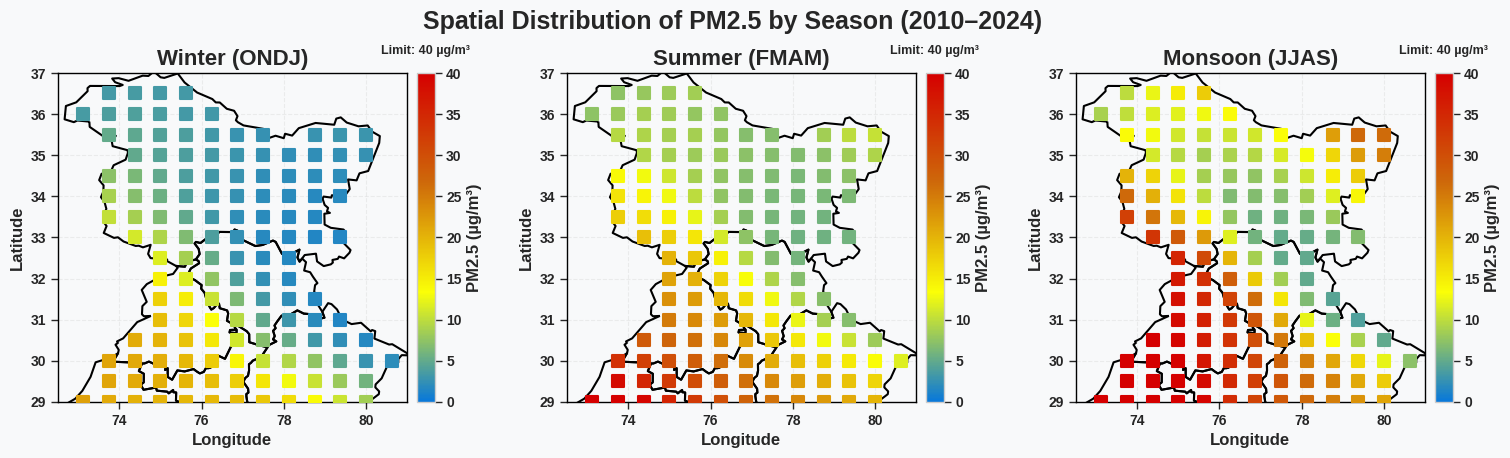

Plot saved to: PM2.5_plot/PM25_seasons_stacked_fixed_scale.png


In [ ]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import geopandas as gpd
from mpl_toolkits.axes_grid1 import make_axes_locatable
from shapely.geometry import Point
from pathlib import Path

# ======== Global Path Settings ========
BASE_DIR = Path()
DATA_DIR = BASE_DIR / 'PM2.5'
SHAPEFILE_PATH = BASE_DIR / 'India Shape'/ 'india_st.shp'
OUTPUT_DIR = Path('PM2.5_plot')

PM25_COLORBAR_MAX = 40  # µg/m³ limit for PM2.5

# ======== Plotting Settings ========
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)
colors = ["#0878DA", "#FBFF07", "#CE690A", '#D50000']
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['figure.titleweight'] = 'bold'



def load_all_pm25_data(start_year=2010, end_year=2024):
    all_data = []
    base_url = "https://raw.githubusercontent.com/yadavrishikesh/Masterclass-IITMandi/refs/heads/main/Module1/data/PM2.5/"

    for year in range(start_year, end_year + 1):
        file_url = f"{base_url}{year}_data.csv"
        try:
            print(f"Reading data from {file_url}")
            df = pd.read_csv(file_url)
            id_vars = ['lat', 'lon']
            value_vars = [col for col in df.columns if col.startswith(f'{year}-')]
            df_long = pd.melt(df, id_vars=id_vars, value_vars=value_vars,
                              var_name='date', value_name='pm25')
            df_long['pm25'] = df_long['pm25'] * 1e9
            df_long['month'] = df_long['date'].str.split('-').str[1].astype(int)
            df_long['year'] = year
            all_data.append(df_long)
        except Exception as e:
            print(f"⚠️ Failed to load {year}: {e}")

    if all_data:
        return pd.concat(all_data, ignore_index=True)
    else:
        raise ValueError("❌ No data files loaded from GitHub!")



def define_seasons(df):
    season_map = {
        1: 'Winter', 2: 'Summer', 3: 'Summer', 4: 'Summer', 5: 'Summer',
        6: 'Monsoon', 7: 'Monsoon', 8: 'Monsoon', 9: 'Monsoon',
        10: 'Winter', 11: 'Winter', 12: 'Winter'
    }
    df['season'] = df['month'].map(season_map)
    return df


def plot_seasons_stacked(df, shapefile_path=SHAPEFILE_PATH, output_dir=OUTPUT_DIR):
    print("Loading shapefile...")
    try:
        gdf = gpd.read_file(shapefile_path)
        print(f"Shapefile loaded with {len(gdf)} features")
        dissolved_shape = gdf.dissolve().reset_index()
        boundary_polygon = dissolved_shape.iloc[0].geometry
    except Exception as e:
        print(f"Error loading shapefile: {e}")
        print("Proceeding without shapefile masking...")
        gdf = None
        boundary_polygon = None

    seasons = ['Winter', 'Summer', 'Monsoon']
    season_labels = ['ONDJ', 'FMAM', 'JJAS']

    wh_bounds = {
        'min_lat': 29,
        'max_lat': 37.0,
        'min_lon': 72.5,
        'max_lon': 81.0
    }

    wh_df = df[(df['lon'] >= wh_bounds['min_lon']) &
               (df['lon'] <= wh_bounds['max_lon']) &
               (df['lat'] >= wh_bounds['min_lat']) &
               (df['lat'] <= wh_bounds['max_lat'])]

    print(f"Filtered to Western Himalayas: {len(wh_df)} records")

    if boundary_polygon is not None:
        geometry = [Point(xy) for xy in zip(wh_df['lon'], wh_df['lat'])]
        mask = [boundary_polygon.contains(point) for point in geometry]
        wh_df = wh_df[mask]
        print(f"Within shapefile boundary: {len(wh_df)} records")

    wh_df = define_seasons(wh_df)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor='white', gridspec_kw={'wspace': 0.35})
    fig.suptitle('Spatial Distribution of PM2.5 by Season (2010–2024)',
                 fontsize=18, fontweight='bold', y=0.95)
    fig.patch.set_facecolor('#f8f9fa')

    custom_cmap = LinearSegmentedColormap.from_list('custom_cmap', colors, N=256)
    norm = plt.Normalize(vmin=0, vmax=PM25_COLORBAR_MAX)

    for i, (season, label) in enumerate(zip(seasons, season_labels)):
        ax = axes[i]
        ax.set_facecolor('#f8f9fa')
        season_data = wh_df[wh_df['season'] == season]
        location_means = season_data.groupby(['lat', 'lon'])['pm25'].mean().reset_index()
        actual_max = location_means['pm25'].max() if not location_means.empty else 0
        print(f"{season} max: {actual_max:.2f}")

        if location_means.empty:
            ax.set_title(f"{season} ({label}) - No Data", fontsize=16, fontweight='bold')
            continue

        if gdf is not None:
            gdf.boundary.plot(ax=ax, color='black', linewidth=1.5, alpha=1.0, zorder=1)

        for _, row in location_means.iterrows():
            color = custom_cmap(norm(row['pm25']))
            ax.scatter(row['lon'], row['lat'], c=[color], alpha=1.0, s=70,
                       marker='s', edgecolors=color, linewidths=1.5, zorder=5)

        scatter = ax.scatter([], [], c=[], cmap=custom_cmap, norm=norm, s=0)
        ax.set_xlim(wh_bounds['min_lon'], wh_bounds['max_lon'])
        ax.set_ylim(wh_bounds['min_lat'], wh_bounds['max_lat'])

        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.1)
        cbar = plt.colorbar(scatter, cax=cax)
        cbar.set_label('PM2.5 (µg/m³)', fontsize=12, fontweight='bold')
        cbar.ax.tick_params(labelsize=10)
        cbar.ax.text(0.5, 1.05, f"Limit: {PM25_COLORBAR_MAX} µg/m³",
                     transform=cbar.ax.transAxes, ha='center', va='bottom',
                     fontsize=9, fontweight='bold')

        ax.set_title(f"{season} ({label})", fontsize=16, fontweight='bold')
        ax.set_xlabel('Longitude', fontsize=12, fontweight='bold')
        ax.set_ylabel('Latitude', fontsize=12, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.1, color='#707070')
        ax.tick_params(axis='both', labelsize=10)

        for tick in ax.get_xticklabels() + ax.get_yticklabels():
            tick.set_fontweight('bold')

        for spine in ax.spines.values():
            spine.set_linewidth = 2.0
            spine.set_color('black')

    plt.tight_layout(rect=[0, 0.03, 1, 0.92])
    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / 'PM25_seasons_stacked_fixed_scale.png'
    plt.show()
    print(f"Plot saved to: {output_path}")
    plt.close()


def main():
    print("Loading PM2.5 data...")
    try:
        download_shapefiles()
        df = load_all_pm25_data()
        print(f"Loaded {len(df)} records.")
        plot_seasons_stacked(df)
    except Exception as e:
        print(f"Error: {e}")
        import traceback
        traceback.print_exc()


if __name__ == "__main__":
    main()


In [ ]:
def load_all_pm25_data_from_github():
    all_data = []
    base_url = "https://raw.githubusercontent.com/yadavrishikesh/Masterclass-IITMandi/main/Module1/data/PM2.5"
    for year in range(2010, 2025):
        url = f"{base_url}/{year}_data.csv"
        try:
            df = pd.read_csv(url)
            id_vars = ['lat', 'lon']
            value_vars = [col for col in df.columns if col.startswith(f'{year}-')]
            df_long = pd.melt(df, id_vars=id_vars, value_vars=value_vars, var_name='date', value_name='pm25')
            df_long['pm25'] = df_long['pm25'] * 1e9
            df_long['month'] = df_long['date'].str.split('-').str[1].astype(int)
            df_long['year'] = year
            all_data.append(df_long)
        except Exception as e:
            print(f"⚠️ Skipping {year}: {e}")
            continue

    if all_data:
        return pd.concat(all_data, ignore_index=True)
    else:
        raise ValueError("❌ No remote data files loaded!")


SPATIAL PLOT FOR PM10

Loading PM10 data...
Reading data from https://raw.githubusercontent.com/yadavrishikesh/Masterclass-IITMandi/main/Module1/data/PM10/2010_data.csv
Reading data from https://raw.githubusercontent.com/yadavrishikesh/Masterclass-IITMandi/main/Module1/data/PM10/2011_data.csv
Reading data from https://raw.githubusercontent.com/yadavrishikesh/Masterclass-IITMandi/main/Module1/data/PM10/2012_data.csv
Reading data from https://raw.githubusercontent.com/yadavrishikesh/Masterclass-IITMandi/main/Module1/data/PM10/2013_data.csv
Reading data from https://raw.githubusercontent.com/yadavrishikesh/Masterclass-IITMandi/main/Module1/data/PM10/2014_data.csv
Reading data from https://raw.githubusercontent.com/yadavrishikesh/Masterclass-IITMandi/main/Module1/data/PM10/2015_data.csv
Reading data from https://raw.githubusercontent.com/yadavrishikesh/Masterclass-IITMandi/main/Module1/data/PM10/2016_data.csv
Reading data from https://raw.githubusercontent.com/yadavrishikesh/Masterclass-IITMandi/main/Module1/dat

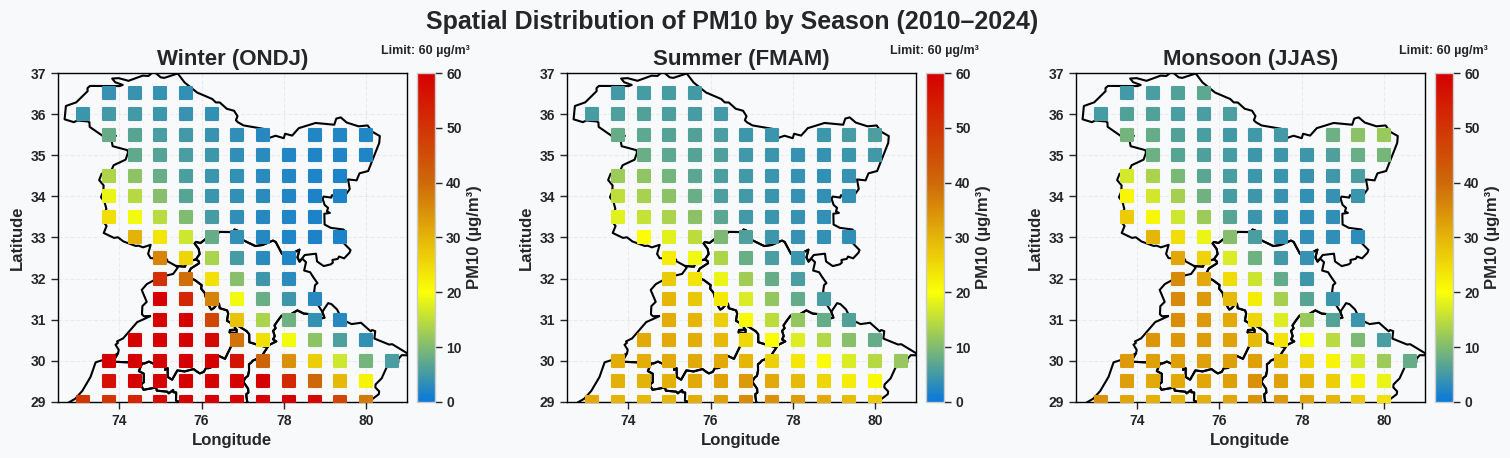

Plot saved to: PM10_plots/PM10_seasons_stacked_fixed_scale.png


In [ ]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import geopandas as gpd
from mpl_toolkits.axes_grid1 import make_axes_locatable
from shapely.geometry import Point
from pathlib import Path

# ======== Global Path Settings ========
BASE_DIR = Path()
DATA_DIR = BASE_DIR / 'PM10'
SHAPEFILE_PATH = BASE_DIR / 'India Shape' / 'india_st.shp'
OUTPUT_DIR = Path('PM10_plots')  # ✅ Correct: Path object



PM10_COLORBAR_MAX = 60  # µg/m³ limit for PM10

# ======== Plotting Settings ========
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)
colors = ["#0878DA", "#FBFF07", "#CE690A", '#D50000']
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['figure.titleweight'] = 'bold'


def load_all_pm10_data():
    base_url = "https://raw.githubusercontent.com/yadavrishikesh/Masterclass-IITMandi/main/Module1/data/PM10"
    all_data = []
    for year in range(2010, 2025):
        file_url = f"{base_url}/{year}_data.csv"
        print(f"Reading data from {file_url}")
        try:
            df = pd.read_csv(file_url)
            id_vars = ['lat', 'lon']
            value_vars = [col for col in df.columns if col.startswith(f'{year}-')]
            df_long = pd.melt(df, id_vars=id_vars, value_vars=value_vars, var_name='date', value_name='pm10')
            df_long['pm10'] = df_long['pm10']
            df_long['month'] = df_long['date'].str.split('-').str[1].astype(int)
            df_long['year'] = year
            all_data.append(df_long)
        except Exception as e:
            print(f"Failed to read {file_url}: {e}")

    if all_data:
        return pd.concat(all_data, ignore_index=True)
    else:
        raise ValueError("No data files found!")


def define_seasons(df):
    season_map = {
        1: 'Winter', 2: 'Summer', 3: 'Summer', 4: 'Summer', 5: 'Summer',
        6: 'Monsoon', 7: 'Monsoon', 8: 'Monsoon', 9: 'Monsoon',
        10: 'Winter', 11: 'Winter', 12: 'Winter'
    }
    df['season'] = df['month'].map(season_map)
    return df


def plot_seasons_stacked(df, shapefile_path=SHAPEFILE_PATH, output_dir=OUTPUT_DIR):
    print("Loading shapefile...")
    try:
        gdf = gpd.read_file(shapefile_path)
        print(f"Shapefile loaded with {len(gdf)} features")
        dissolved_shape = gdf.dissolve().reset_index()
        boundary_polygon = dissolved_shape.iloc[0].geometry
    except Exception as e:
        print(f"Error loading shapefile: {e}")
        print("Proceeding without shapefile masking...")
        gdf = None
        boundary_polygon = None

    seasons = ['Winter', 'Summer', 'Monsoon']
    season_labels = ['ONDJ', 'FMAM', 'JJAS']

    wh_bounds = {
        'min_lat': 29,
        'max_lat': 37.0,
        'min_lon': 72.5,
        'max_lon': 81.0
    }

    wh_df = df[(df['lon'] >= wh_bounds['min_lon']) &
               (df['lon'] <= wh_bounds['max_lon']) &
               (df['lat'] >= wh_bounds['min_lat']) &
               (df['lat'] <= wh_bounds['max_lat'])]

    print(f"Filtered to Western Himalayas: {len(wh_df)} records")

    if boundary_polygon is not None:
        geometry = [Point(xy) for xy in zip(wh_df['lon'], wh_df['lat'])]
        mask = [boundary_polygon.contains(point) for point in geometry]
        wh_df = wh_df[mask]
        print(f"Within shapefile boundary: {len(wh_df)} records")

    wh_df = define_seasons(wh_df)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor='white', gridspec_kw={'wspace': 0.35})
    fig.suptitle('Spatial Distribution of PM10 by Season (2010–2024)',
                 fontsize=18, fontweight='bold', y=0.95)
    fig.patch.set_facecolor('#f8f9fa')

    custom_cmap = LinearSegmentedColormap.from_list('custom_cmap', colors, N=256)
    norm = plt.Normalize(vmin=0, vmax=PM10_COLORBAR_MAX)

    for i, (season, label) in enumerate(zip(seasons, season_labels)):
        ax = axes[i]
        ax.set_facecolor('#f8f9fa')
        season_data = wh_df[wh_df['season'] == season]
        location_means = season_data.groupby(['lat', 'lon'])['pm10'].mean().reset_index()
        actual_max = location_means['pm10'].max() if not location_means.empty else 0
        print(f"{season} max: {actual_max:.2f}")

        if location_means.empty:
            ax.set_title(f"{season} ({label}) - No Data", fontsize=16, fontweight='bold')
            continue

        if gdf is not None:
            gdf.boundary.plot(ax=ax, color='black', linewidth=1.5, alpha=1.0, zorder=1)

        for _, row in location_means.iterrows():
            color = custom_cmap(norm(row['pm10']))
            ax.scatter(row['lon'], row['lat'], c=[color], alpha=1.0, s=70,
                       marker='s', edgecolors=color, linewidths=1.5, zorder=5)

        scatter = ax.scatter([], [], c=[], cmap=custom_cmap, norm=norm, s=0)
        ax.set_xlim(wh_bounds['min_lon'], wh_bounds['max_lon'])
        ax.set_ylim(wh_bounds['min_lat'], wh_bounds['max_lat'])

        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.1)
        cbar = plt.colorbar(scatter, cax=cax)
        cbar.set_label('PM10 (µg/m³)', fontsize=12, fontweight='bold')
        cbar.ax.tick_params(labelsize=10)
        cbar.ax.text(0.5, 1.05, f"Limit: {PM10_COLORBAR_MAX} µg/m³",
                     transform=cbar.ax.transAxes, ha='center', va='bottom',
                     fontsize=9, fontweight='bold')

        ax.set_title(f"{season} ({label})", fontsize=16, fontweight='bold')
        ax.set_xlabel('Longitude', fontsize=12, fontweight='bold')
        ax.set_ylabel('Latitude', fontsize=12, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.1, color='#707070')
        ax.tick_params(axis='both', labelsize=10)

        for tick in ax.get_xticklabels() + ax.get_yticklabels():
            tick.set_fontweight('bold')

        for spine in ax.spines.values():
            spine.set_linewidth = 2.0
            spine.set_color('black')

    plt.tight_layout(rect=[0, 0.03, 1, 0.92])
    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / 'PM10_seasons_stacked_fixed_scale.png'
    plt.show()
    print(f"Plot saved to: {output_path}")
    plt.close()


def main():
    print("Loading PM10 data...")
    try:
        df = load_all_pm10_data()
        print(f"Loaded {len(df)} records.")
        plot_seasons_stacked(df)
    except Exception as e:
        print(f"Error: {e}")
        import traceback
        traceback.print_exc()


if __name__ == "__main__":
    main()


WIND ROSE PLOTS

=== COMPACT REGIONAL WIND ROSE ANALYSIS ===
✅ Successfully loaded wind data: 45645 records

Pre-monsoon Season Regional Statistics:
  Mean wind speed: 3.90 ± 1.29 m/s
  Max wind speed: 10.36 m/s
  Total data points: 15,300
  Number of locations: 255
  Dominant wind direction: 237.1° (WSW)

Monsoon Season Regional Statistics:
  Mean wind speed: 2.95 ± 1.15 m/s
  Max wind speed: 8.24 m/s
  Total data points: 15,300
  Number of locations: 255
  Dominant wind direction: 263.0° (W)

Post-monsoon Season Regional Statistics:
  Mean wind speed: 3.55 ± 1.26 m/s
  Max wind speed: 9.66 m/s
  Total data points: 15,045
  Number of locations: 255
  Dominant wind direction: 232.2° (SW)


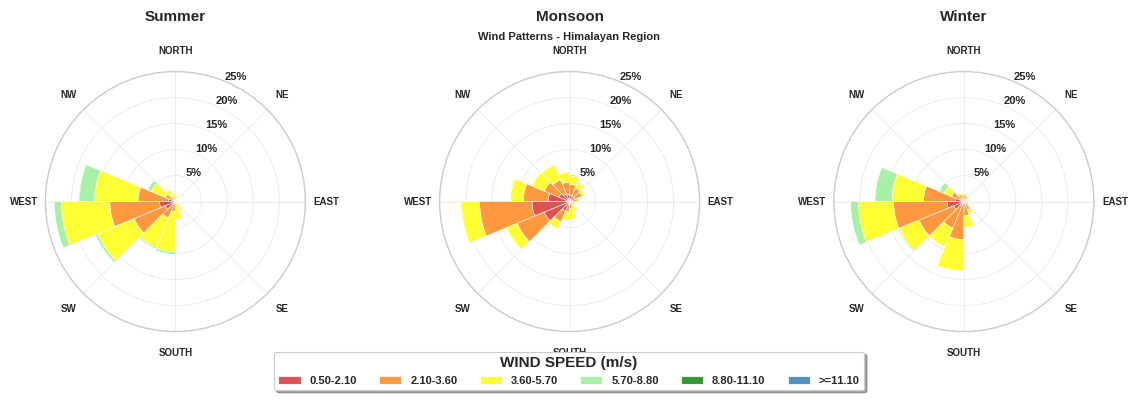


✅ Compact regional wind rose plot saved as: wind_plots/regional_three_season_wind_roses_compact.png

✅ Compact regional wind rose analysis completed!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

class CompactWindRoseAnalyzer:
    def __init__(self, wind_speed_dir, wind_direction_dir, unit_conversion=1.0):

        self.wind_speed_dir = wind_speed_dir
        self.wind_direction_dir = wind_direction_dir
        self.unit_conversion = unit_conversion
        self.wind_data = None

        # Wind speed bins and colors
        self.speed_bins = [0.5, 2.10, 3.60, 5.70, 8.80, 11.10, float('inf')]
        self.speed_labels = ['0.50-2.10', '2.10-3.60', '3.60-5.70',
                           '5.70-8.80', '8.80-11.10', '>=11.10']
        self.speed_colors = ['#d62728', '#ff7f0e', '#ffff00', '#90EE90', '#008000', '#1f77b4']
    def classify_season(self, month):
        """Classify month into seasons"""
        if month in [6, 7, 8, 9]:
            return 'Monsoon'
        elif month in [2,3, 4, 5]:
            return 'Pre-monsoon'
        elif month in [10, 11, 12,1]:
            return 'Post-monsoon'
        else:
            return 'Winter' # Note: The original code didn't handle other cases, added 'Winter' as a fallback



    def load_wind_data(self):
      """Load wind speed and direction CSV files from GitHub"""
      base_url = "https://raw.githubusercontent.com/yadavrishikesh/Masterclass-IITMandi/main/Module1/data"
      years = range(2010, 2025)

      all_speed_dfs = []
      all_direction_dfs = []

      for year in years:
          speed_url = f"{base_url}/Wind_Speed/{year}_winddata.csv"
          dir_url = f"{base_url}/WIND_DIR/{year}_wind_direction.csv"

          try:
              df_speed = pd.read_csv(speed_url)
              for col in df_speed.columns:
                  if col not in ['lat', 'lon']:
                      df_speed[col] = df_speed[col] * self.unit_conversion

              df_speed_long = pd.melt(df_speed, id_vars=['lat', 'lon'],
                                      var_name='month_col', value_name='wind_speed')
              df_speed_long['month'] = df_speed_long['month_col'].str.split('-').str[1]
              df_speed_long['year'] = year
              df_speed_long['datetime'] = pd.to_datetime(df_speed_long['month_col'])
              all_speed_dfs.append(df_speed_long)

          except Exception as e:
              print(f"⚠️ Error loading wind speed for {year}: {e}")
              continue

          try:
              df_dir = pd.read_csv(dir_url)
              df_dir_long = pd.melt(df_dir, id_vars=['lat', 'lon'],
                                    var_name='month_col', value_name='wind_direction')
              df_dir_long['month'] = df_dir_long['month_col'].str.split('-').str[1]
              df_dir_long['year'] = year
              df_dir_long['datetime'] = pd.to_datetime(df_dir_long['month_col'])
              all_direction_dfs.append(df_dir_long)

          except Exception as e:
              print(f"⚠️ Error loading wind direction for {year}: {e}")
              continue

      if not all_speed_dfs or not all_direction_dfs:
          print("❌ No valid data files could be loaded")
          return False

      # Merge wind speed and direction
      wind_speed_data = pd.concat(all_speed_dfs, ignore_index=True)
      wind_direction_data = pd.concat(all_direction_dfs, ignore_index=True)

      self.wind_data = pd.merge(
          wind_speed_data,
          wind_direction_data,
          on=['lat', 'lon', 'month_col', 'month', 'year', 'datetime']
      )

      # Add season classification
      self.wind_data['month_num'] = self.wind_data['month'].astype(int)
      self.wind_data['season'] = self.wind_data['month_num'].apply(self.classify_season)

      print(f"✅ Successfully loaded wind data: {len(self.wind_data)} records")
      return True


      def classify_season(self, month):
          """Classify month into seasons"""
          if month in [6, 7, 8, 9]:
              return 'Monsoon'
          elif month in [2,3, 4, 5]:
              return 'Pre-monsoon'
          elif month in [10, 11, 12,1]:
              return 'Post-monsoon'
          else:
              return 'Winter'

    def calculate_wind_rose_data(self, wind_speeds, wind_directions):
        """Calculate wind rose data for plotting"""
        # Remove invalid data
        valid_mask = (~np.isnan(wind_speeds)) & (~np.isnan(wind_directions))
        speeds = wind_speeds[valid_mask]
        directions = wind_directions[valid_mask]

        if len(speeds) == 0:
            return None, None, 0.0

        # Calculate calm conditions
        calm_threshold = 0.5
        calm_percentage = (speeds < calm_threshold).sum() / len(speeds) * 100

        # Remove calm conditions
        active_mask = speeds >= calm_threshold
        active_speeds = speeds[active_mask]
        active_directions = directions[active_mask]

        if len(active_speeds) == 0:
            return None, None, calm_percentage

        # Bin directions (16 sectors)
        dir_bin_width = 360 / 16
        dir_bin_centers = np.arange(dir_bin_width/2, 360, dir_bin_width)

        # Initialize arrays
        rose_data = np.zeros((len(self.speed_bins)-1, len(dir_bin_centers)))

        # Assign to bins
        dir_indices = np.digitize((active_directions + dir_bin_width/2) % 360,
                                 np.arange(0, 361, dir_bin_width)) - 1
        dir_indices = np.clip(dir_indices, 0, len(dir_bin_centers)-1)

        speed_indices = np.digitize(active_speeds, self.speed_bins) - 1
        speed_indices = np.clip(speed_indices, 0, len(self.speed_bins)-2)

        # Calculate frequencies
        for i in range(len(active_speeds)):
            rose_data[speed_indices[i], dir_indices[i]] += 1

        # Convert to percentages
        total_count = len(active_speeds)
        rose_data = (rose_data / total_count) * 100

        return rose_data, dir_bin_centers, calm_percentage

    def create_wind_rose_plot(self, wind_speeds, wind_directions, title, ax):
        """Create a compact wind rose plot"""

        # Calculate wind rose data
        rose_data, dir_centers, calm_percentage = self.calculate_wind_rose_data(
            wind_speeds, wind_directions)

        if rose_data is None:
            ax.text(0.5, 0.5, 'No Data Available', transform=ax.transAxes,
                   ha='center', va='center', fontsize=10, fontweight='bold')
            ax.set_title(title, pad=20, fontsize=11, fontweight='bold')
            return

        # Convert direction centers to radians
        theta = np.radians(dir_centers)
        width = np.radians(360 / len(dir_centers))

        # Plot each speed bin
        bottom = np.zeros(len(dir_centers))

        for i, (speed_label, color) in enumerate(zip(self.speed_labels, self.speed_colors)):
            values = rose_data[i, :]
            bars = ax.bar(theta, values, width=width, bottom=bottom,
                         color=color, alpha=0.8,
                         edgecolor='white', linewidth=0.5)
            bottom += values

        # Customize the plot
        ax.set_theta_zero_location('N')
        ax.set_theta_direction(-1)

        # Set compass directions
        ax.set_thetagrids(np.arange(0, 360, 45),
                         ['NORTH', 'NE', 'EAST', 'SE', 'SOUTH', 'SW', 'WEST', 'NW'],
                         fontsize=7, fontweight='bold')

        # Set radial limits and labels
        max_freq = np.max(np.sum(rose_data, axis=0))
        if max_freq > 0:
            if max_freq <= 5:
                r_max = 5
            elif max_freq <= 10:
                r_max = 10
            elif max_freq <= 15:
                r_max = 15
            else:
                r_max = np.ceil(max_freq / 5) * 5

            ax.set_ylim(0, r_max)

            # Add percentage labels
            if r_max <= 10:
                r_ticks = np.arange(0, r_max + 1, 2)
            else:
                r_ticks = np.arange(0, r_max + 1, 5)

            ax.set_yticks(r_ticks)
            ax.set_yticklabels([f'{r:.0f}%' if r > 0 else '' for r in r_ticks],
                              fontsize=8)

        # Add grid
        ax.grid(True, alpha=0.4, linewidth=0.6)
        ax.set_axisbelow(True)

        # Add title
        ax.set_title(title, pad=25, fontsize=11, fontweight='bold')



        return ax

    def create_regional_wind_roses(self, output_dir='wind_plots'):
        """Create compact regional wind rose plots for three main seasons"""
        os.makedirs(output_dir, exist_ok=True)

        seasons = ['Pre-monsoon', 'Monsoon', 'Post-monsoon']
        season_labels = ['Summer\n', 'Monsoon\n', 'Winter\n']

        # Create compact figure
        fig, axes = plt.subplots(1, 3, figsize=(12, 4),
                               subplot_kw=dict(projection='polar'))

        fig.suptitle('Wind Patterns - Himalayan Region',
                    fontsize=8, fontweight='bold', y=0.95)

        # Store data for statistics
        season_data = {}

        for i, (season, season_label) in enumerate(zip(seasons, season_labels)):
            # Get ALL data for this season from ALL locations
            season_wind_data = self.wind_data[self.wind_data['season'] == season]
            season_data[season] = season_wind_data

            if len(season_wind_data) == 0:
                axes[i].text(0.5, 0.5, f'No {season} Data',
                           transform=axes[i].transAxes, ha='center', va='center',
                           fontsize=10, fontweight='bold')
                axes[i].set_title(season_label, pad=20, fontsize=11, fontweight='bold')
                continue

            # Create wind rose using ALL regional data
            self.create_wind_rose_plot(
                season_wind_data['wind_speed'].values,
                season_wind_data['wind_direction'].values,
                season_label, axes[i]
            )

            # Print season statistics
            speeds = season_wind_data['wind_speed'].values
            directions = season_wind_data['wind_direction'].values
            valid_data = (~np.isnan(speeds)) & (~np.isnan(directions))

            if np.any(valid_data):
                mean_speed = np.mean(speeds[valid_data])
                max_speed = np.max(speeds[valid_data])
                std_speed = np.std(speeds[valid_data])
                n_locations = len(season_wind_data[['lat', 'lon']].drop_duplicates())

                print(f"\n{season} Season Regional Statistics:")
                print(f"  Mean wind speed: {mean_speed:.2f} ± {std_speed:.2f} m/s")
                print(f"  Max wind speed: {max_speed:.2f} m/s")
                print(f"  Total data points: {np.sum(valid_data):,}")
                print(f"  Number of locations: {n_locations}")

                # Calculate dominant wind direction
                valid_directions = directions[valid_data]
                if len(valid_directions) > 0:
                    x_component = np.cos(np.radians(valid_directions))
                    y_component = np.sin(np.radians(valid_directions))
                    mean_x = np.mean(x_component)
                    mean_y = np.mean(y_component)
                    dominant_direction = (np.degrees(np.arctan2(mean_y, mean_x)) + 360) % 360

                    # Convert to compass direction
                    compass_dirs = ['N', 'NNE', 'NE', 'ENE', 'E', 'ESE', 'SE', 'SSE',
                                  'S', 'SSW', 'SW', 'WSW', 'W', 'WNW', 'NW', 'NNW']
                    dir_index = int((dominant_direction + 11.25) / 22.5) % 16
                    dominant_compass = compass_dirs[dir_index]

                    print(f"  Dominant wind direction: {dominant_direction:.1f}° ({dominant_compass})")

        # Create compact legend
        handles, labels = [], []
        for speed_label, color in zip(self.speed_labels, self.speed_colors):
            handle = plt.Rectangle((0,0),1,1, facecolor=color, alpha=0.8, edgecolor='white')
            handles.append(handle)
            labels.append(speed_label)

        # Position legend below the plots
        legend = fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0.04),
                          ncol=len(labels), title='WIND SPEED (m/s)',
                          fontsize=8, title_fontsize=11, frameon=True, fancybox=True, shadow=True)
        legend.get_title().set_fontweight('bold')

        plt.tight_layout()
        plt.subplots_adjust(bottom=0.20, top=0.85)

        # Save plot
        filename = f'regional_three_season_wind_roses_compact.png'
        filepath = os.path.join(output_dir, filename)
        plt.savefig(filepath, dpi=300, bbox_inches='tight', facecolor='white')
        plt.show()

        print(f"\n✅ Compact regional wind rose plot saved as: {filepath}")
        return fig, season_data


# Quick usage function
def create_compact_regional_wind_roses(wind_speed_dir, wind_direction_dir):
    """Quick function to create compact regional wind roses"""
    print("=== COMPACT REGIONAL WIND ROSE ANALYSIS ===")

    analyzer = CompactWindRoseAnalyzer(wind_speed_dir, wind_direction_dir)

    if not analyzer.load_wind_data():
        print("❌ Failed to load wind data")
        return False

    # Create compact regional wind roses
    fig, season_data = analyzer.create_regional_wind_roses()

    print("\n✅ Compact regional wind rose analysis completed!")
    return True

if __name__ == "__main__":
    # Define the base path relative to the script's location
    base_dir = Path()

    # Define wind speed and direction directories
    wind_speed_directory = None
    wind_direction_directory = None

    # Create compact regional wind roses
    create_compact_regional_wind_roses(wind_speed_directory, wind_direction_directory)


BIVARIATE POLAR PLOTS

Loading seasonal data from folders...
Winter: Mean PM2.5 = 6.3 µg/m³
Summer: Mean PM2.5 = 17.2 µg/m³
Monsoon: Mean PM2.5 = 25.6 µg/m³
Creating seasonal bipolar plots...


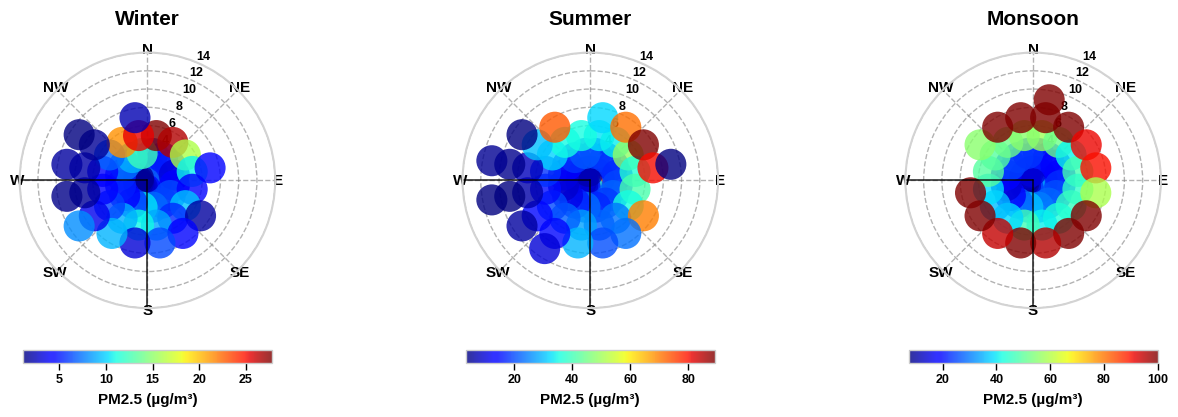

Saved figure as 'Proper_Bipolar_WindRose_PM2.5_updated.png'


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def create_seasonal_bipolar_plots(seasonal_data, figsize=(15, 5)):
    fig, axes = plt.subplots(1, 3, figsize=figsize, subplot_kw=dict(projection='polar'))
    fig.subplots_adjust(wspace=0.6, top=0.85, bottom=0.15)  # Add padding between plots

    seasons = ['Winter', 'Summer', 'Monsoon']

    for i, season in enumerate(seasons):
        if len(seasonal_data[season]['pm25']) == 0:
            continue

        ws = seasonal_data[season]['wind_speed']
        wd = seasonal_data[season]['wind_direction']
        pm25 = seasonal_data[season]['pm25']

        ax = axes[i]
        ws_bins = [0, 2, 4, 6, 8, 10, 12, 14]
        wd_bins = 16
        wd_bin_edges = np.linspace(0, 360, wd_bins + 1)
        wd_bin_centers = (wd_bin_edges[:-1] + wd_bin_edges[1:]) / 2
        wd_rad = np.deg2rad(wd_bin_centers)

        pm25_grid = np.full((len(wd_bin_centers), len(ws_bins)-1), np.nan)

        for j, wd_center in enumerate(wd_bin_centers):
            wd_min = wd_bin_edges[j]
            wd_max = wd_bin_edges[j + 1]
            wd_mask = (wd >= wd_min) & (wd < wd_max) if j < len(wd_bin_centers) - 1 else (wd >= wd_min) | (wd < wd_max - 360)

            for k in range(len(ws_bins) - 1):
                ws_min = ws_bins[k]
                ws_max = ws_bins[k + 1]
                ws_mask = (ws >= ws_min) & (ws < ws_max)
                combined_mask = wd_mask & ws_mask
                if np.sum(combined_mask) > 0:
                    pm25_grid[j, k] = np.mean(pm25[combined_mask])

        valid_pm25 = pm25_grid[~np.isnan(pm25_grid)]
        if len(valid_pm25) > 0:
            vmin = np.min(valid_pm25)
            vmax = np.max(valid_pm25)
            if season == 'Monsoon':
                vmax = min(vmax, 100)
                if vmax < 50:
                    vmax = 50
        else:
            vmin, vmax = 0, 50

        scatter = None
        for k in range(len(ws_bins) - 1):
            pm25_ring = pm25_grid[:, k]
            valid_mask = ~np.isnan(pm25_ring)
            if np.sum(valid_mask) > 0:
                r = np.full(len(wd_rad), (ws_bins[k] + ws_bins[k + 1]) / 2)
                scatter = ax.scatter(wd_rad[valid_mask], r[valid_mask],
                                     c=pm25_ring[valid_mask],
                                     s=500, cmap='jet', alpha=0.8,
                                     vmin=vmin, vmax=vmax,
                                     edgecolors='none')

        ax.set_theta_zero_location('N')
        ax.set_theta_direction(-1)
        ax.set_ylim(0, 14)
        ax.tick_params(pad=-10)
        ax.set_yticks([2, 4, 6, 8, 10, 12, 14])
        ax.set_yticklabels([str(v) for v in [2, 4, 6, 8, 10, 12, 14]],
                           fontsize=9, color='black', fontweight='bold')

        ax.set_thetagrids(np.arange(0, 360, 45),
                          ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW'],
                          fontsize=11, fontweight='bold', color='black')

        ax.plot([0, np.pi], [0, 14], 'k-', linewidth=1.2, alpha=0.8)
        ax.plot([np.pi/2, 3*np.pi/2], [0, 14], 'k-', linewidth=1.2, alpha=0.8)

        ax.grid(True, alpha=0.6, linewidth=1.0, color='gray', linestyle='--')
        ax.set_facecolor('white')
        ax.spines['polar'].set_color('lightgrey')
        ax.spines['polar'].set_linewidth(1.5)

        ax.set_title(season, fontweight='bold', fontsize=15, color='black', pad=20)

        # Add colorbar BELOW each subplot
        if scatter:
            cbar = fig.colorbar(scatter, ax=ax, orientation='horizontal', pad=0.12, shrink=0.9)
            cbar.ax.set_xlabel("PM2.5 (µg/m³)", fontsize=11, fontweight='bold', labelpad=5, color='black')
            cbar.ax.tick_params(labelsize=9, colors='black')
            for label in cbar.ax.get_xticklabels():
                label.set_fontweight('bold')

    return fig

def load_seasonal_data_from_github(pm25_folder=None, ws_folder=None, wd_folder=None, years=range(2010, 2025)):
    season_months = {
        'Winter': [10, 11, 12, 1],
        'Summer': [2, 3, 4, 5],
        'Monsoon': [6, 7, 8, 9]
    }

    seasonal_data = {}

    for season, months in season_months.items():
        all_pm25, all_ws, all_wd = [], [], []
        for year in years:
            try:
                # Build GitHub raw URLs
                pm25_url = f"https://raw.githubusercontent.com/yadavrishikesh/Masterclass-IITMandi/main/Module1/data/PM2.5/{year}_data.csv"
                ws_url = f"https://raw.githubusercontent.com/yadavrishikesh/Masterclass-IITMandi/main/Module1/data/Wind_Speed/{year}_winddata.csv"
                wd_url = f"https://raw.githubusercontent.com/yadavrishikesh/Masterclass-IITMandi/main/Module1/data/WIND_DIR/{year}_wind_direction.csv"

                # Read data from GitHub
                pm25_df = pd.read_csv(pm25_url)
                ws_df = pd.read_csv(ws_url)
                wd_df = pd.read_csv(wd_url)

                for month in months:
                    # Handle cross-year case for Winter
                    target_year = year - 1 if (season == 'Winter' and month in [10, 11, 12]) else year
                    col = f"{target_year}-{month:02d}"
                    if col in pm25_df and col in ws_df and col in wd_df:
                        pm25 = pm25_df[col].dropna() * 1e9
                        ws = ws_df[col].dropna()
                        wd = wd_df[col].dropna()
                        min_len = min(len(pm25), len(ws), len(wd))
                        if min_len > 0:
                            all_pm25.extend(pm25[:min_len])
                            all_ws.extend(ws[:min_len])
                            all_wd.extend(wd[:min_len])
            except Exception as e:
                print(f"⚠️ Error loading data for year {year}: {e}")
                continue

        seasonal_data[season] = {
            'pm25': np.array(all_pm25),
            'wind_speed': np.array(all_ws),
            'wind_direction': np.array(all_wd)
        }

        if len(all_pm25) > 0:
            print(f"{season}: Mean PM2.5 = {np.mean(all_pm25):.1f} µg/m³")

    return seasonal_data


def main():
    base_path = Path()
    pm25_folder = base_path / "PM2.5"
    ws_folder = base_path / "Wind_Speed"
    wd_folder = base_path / "WIND_DIR"

    print("Loading seasonal data from folders...")
    seasonal_data = load_seasonal_data_from_github(pm25_folder, ws_folder, wd_folder)

    if all(len(seasonal_data[season]['pm25']) == 0 for season in seasonal_data):
        print("No valid data found. Check paths or files.")
        return

    print("Creating seasonal bipolar plots...")
    fig = create_seasonal_bipolar_plots(seasonal_data)
    plt.show()
    fig.savefig("Proper_Bipolar_WindRose_PM2.5_updated.png", dpi=300, bbox_inches='tight')
    print("Saved figure as 'Proper_Bipolar_WindRose_PM2.5_updated.png'")

if __name__ == "__main__":
    main()
